# Punishment Study 2.1.2 — NLP Pipeline
## Notebook 1: Preprocessing and Basic Features

**Author:** David G. Kamper  
**Project:** *Is Criminal Punishment Prosocial?*  
**Pipeline stage:** 1 of 4

---

### What this notebook does

This is the **CPU-only feature extraction stage**. It takes the cleaned dataset produced by `01_main_analysis.Rmd` (Phase 11 output) and extracts:

1. **Text cleaning** — lowercase, whitespace normalization, character filtering, NA handling for both open-ended responses (`Sentence_OpenEnd1`, `Sentence_OpenEnd2`)
2. **Word counts** — per-question and combined; filter to responses with ≥ 3 words
3. **VADER sentiment** — neg/neu/pos/compound for each question and combined
4. **Empath lexicon** — 26 thematic categories (violence, crime, suffering, sympathy, etc.)
5. **Custom punishment dictionary** — 10 categories (deterrence, incapacitation, rehabilitation, retribution, norm_expression, revenge, suffering, degradation, exclusion, victim_focus) with prosocial/dark aggregates
6. **Quality diagnostics** — distributions, sample extreme responses

### Pipeline context

| Notebook | Purpose | Output |
|----------|---------|--------|
| **01 (this)** | Preprocessing + dictionaries + VADER + Empath | `01_basic_features.csv` |
| 02 | DeBERTa-v3 + Claude Haiku 4.5 zero-shot classification | `02_classification_features.csv` |
| 03 | BGE-large + voyage-4-large embeddings + prototype similarity | `03_embedding_features.csv` |
| 04 | BERTopic + UMAP + cross-method convergence + facade + export | `punishment_212_nlp_features.csv` |

### Runtime

**No GPU required.** Total runtime ≈ 2–3 minutes on free Colab.

### Setup

Runtime → Change runtime type → CPU is fine (GPU not needed for this notebook).


---

## Section 0: Install packages and imports


In [1]:
# === INSTALL PACKAGES ===
# Light install — only what notebook 1 needs (no transformers, no GPU libs)
!pip install -q vaderSentiment empath
print('✓ Packages installed')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.0 MB/s eta 0:00:00
✓ Packages installed


In [2]:
# === IMPORTS ===
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from empath import Empath

from google.colab import files

# Display options
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
np.set_printoptions(suppress=True, precision=4)

print('✓ Imports complete')


✓ Imports complete


---

## Section 1: Load cleaned data

Upload `punishment_212_cleaned_data.csv` produced by Phase 11 of `01_main_analysis.Rmd` (it lives in `data/cleaned/` in your local Analysis folder).

Expected: 496 rows, 145 columns including `Sentence_OpenEnd1`, `Sentence_OpenEnd2`, `punitiveness_agg`, `hostile_agg`, etc.


In [3]:
# === UPLOAD CLEANED CSV ===
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(f'✓ Loaded: {filename}')
print(f'  Rows: {len(df)}')
print(f'  Columns: {len(df.columns)}')

# Sanity check on critical columns
required = ['Sentence_OpenEnd1', 'Sentence_OpenEnd2', 'punitiveness_agg', 'hostile_agg',
            'crime_concerns_agg', 'ResponseId', 'vignette']
missing = [c for c in required if c not in df.columns]
if missing:
    print(f'  ⚠ Missing columns: {missing}')
else:
    print(f'  ✓ All required columns present')


Saving punishment_212_cleaned_data.csv to punishment_212_cleaned_data.csv
✓ Loaded: punishment_212_cleaned_data.csv
  Rows: 496
  Columns: 145
  ✓ All required columns present


---

## Section 2: Text preprocessing

**Cleaning steps:**
1. Lowercase
2. Collapse whitespace
3. Strip non-alphanumeric/punctuation characters
4. Handle NA → empty string

**Combination:** `text_combined = text1_clean + ' ' + text2_clean` because the two prompts (justification + goals) tap closely related constructs.

**Filter:** Responses with combined word count < 3 are excluded from text analyses (gibberish, blanks, single-word non-answers like "yes"). The original DataFrame is preserved as `df` so quantitative columns remain available; text-analytic features are computed on `df_valid`.


In [4]:
# === TEXT CLEANING ===
def clean_text(text):
    """Lowercase, normalize whitespace, strip non-text characters, handle NA."""
    if pd.isna(text) or text == '':
        return ''
    text = str(text).lower()
    text = ' '.join(text.split())
    text = re.sub(r'[^a-z0-9\s\.\,\!\?\'\-]', '', text)
    return text.strip()

df['text1_clean'] = df['Sentence_OpenEnd1'].apply(clean_text)
df['text2_clean'] = df['Sentence_OpenEnd2'].apply(clean_text)
df['text_combined'] = df.apply(
    lambda r: f"{r['text1_clean']} {r['text2_clean']}".strip(), axis=1)

# Word counts
df['text1_wordcount'] = df['text1_clean'].apply(lambda x: len(x.split()) if x else 0)
df['text2_wordcount'] = df['text2_clean'].apply(lambda x: len(x.split()) if x else 0)
df['text_combined_wordcount'] = df['text1_wordcount'] + df['text2_wordcount']

# Validity filter (≥ 3 words combined)
df_valid = df[df['text_combined_wordcount'] >= 3].copy()

n_dropped = len(df) - len(df_valid)
print(f'✓ Text cleaning complete')
print(f'  Total responses:       {len(df)}')
print(f'  Valid (≥3 words):      {len(df_valid)}')
print(f'  Dropped (insufficient): {n_dropped}')
print()
print(f'  Mean word count Q1 (justification): {df_valid["text1_wordcount"].mean():.1f}')
print(f'  Mean word count Q2 (goals):         {df_valid["text2_wordcount"].mean():.1f}')
print(f'  Mean word count combined:           {df_valid["text_combined_wordcount"].mean():.1f}')


✓ Text cleaning complete
  Total responses:       496
  Valid (≥3 words):      496
  Dropped (insufficient): 0

  Mean word count Q1 (justification): 28.8
  Mean word count Q2 (goals):         19.5
  Mean word count combined:           48.3


In [5]:
# === SAMPLE RESPONSES ===
print('=== SAMPLE RESPONSES (first 3) ===\n')
for i in range(min(3, len(df_valid))):
    print(f'--- Response {i+1} (ResponseId: {df_valid["ResponseId"].iloc[i]}) ---')
    print(f'Q1 (Why this sentence): {df_valid["Sentence_OpenEnd1"].iloc[i]}')
    print(f'Q2 (What it accomplishes): {df_valid["Sentence_OpenEnd2"].iloc[i]}')
    print(f'Word count: {df_valid["text_combined_wordcount"].iloc[i]}\n')


=== SAMPLE RESPONSES (first 3) ===

--- Response 1 (ResponseId: R_59oJsB5QgHY033K) ---
Q1 (Why this sentence): This was a violent robbery that escalated into a fatal attack
Q2 (What it accomplishes): accountability and rehabilitation 
Word count: 14

--- Response 2 (ResponseId: R_5HNwntvu43Uc9qk) ---
Q1 (Why this sentence): he deserves jailtime
Q2 (What it accomplishes): rehabilitate and remind
Word count: 6

--- Response 3 (ResponseId: R_3M2SAikyTMiTcKl) ---
Q1 (Why this sentence): Darryl killed a completely innocent woman, and a stranger, for no reason at all, and in my opinion has forfeit any right to freedom or a normal life because of this.
Q2 (What it accomplishes): Removal of a dangerous and deranged person from society where he cannot harm anyone else.
Word count: 46



---

## Section 3: VADER sentiment

VADER (Valence Aware Dictionary and sEntiment Reasoner) provides four scores per text:
- `neg` (negative valence proportion, 0–1)
- `neu` (neutral valence proportion, 0–1)
- `pos` (positive valence proportion, 0–1)
- `compound` (normalized aggregate score, −1 to +1)

We compute these separately for Q1, Q2, and combined text.

**Expected pattern:** Punishment justifications tend to be highly negative (mean compound ≈ −0.50 in v1 pipeline), reflecting the violence/crime content of the vignettes themselves rather than evaluation-specific affect.


In [6]:
# === VADER SENTIMENT ===
vader = SentimentIntensityAnalyzer()

def get_vader(text):
    if not text:
        return {'neg': np.nan, 'neu': np.nan, 'pos': np.nan, 'compound': np.nan}
    return vader.polarity_scores(text)

print('Computing VADER scores...')

# Q1
v1 = df_valid['text1_clean'].apply(get_vader).apply(pd.Series)
v1.columns = ['vader1_neg', 'vader1_neu', 'vader1_pos', 'vader1_compound']

# Q2
v2 = df_valid['text2_clean'].apply(get_vader).apply(pd.Series)
v2.columns = ['vader2_neg', 'vader2_neu', 'vader2_pos', 'vader2_compound']

# Combined
vc = df_valid['text_combined'].apply(get_vader).apply(pd.Series)
vc.columns = ['vader_neg', 'vader_neu', 'vader_pos', 'vader_compound']

df_valid = pd.concat([df_valid, v1, v2, vc], axis=1)

print(f'✓ VADER complete')
print(f'  Mean compound (Q1):       {df_valid["vader1_compound"].mean():.3f}')
print(f'  Mean compound (Q2):       {df_valid["vader2_compound"].mean():.3f}')
print(f'  Mean compound (combined): {df_valid["vader_compound"].mean():.3f}')


Computing VADER scores...
✓ VADER complete
  Mean compound (Q1):       -0.540
  Mean compound (Q2):       -0.087
  Mean compound (combined): -0.501


---

## Section 4: Empath lexicon

Empath provides counts (normalized) of words matching pre-built lexical categories. We track 26 categories chosen for theoretical relevance to the punishment domain:

| Group | Categories |
|---|---|
| Violence/harm | violence, crime, death, pain, suffering, weapon, fight, kill |
| Negative affect | negative_emotion, anger, fear, hate, disgust |
| Prosocial | sympathy, help, healing, trust, achievement |
| Institutional | government, law, order, power, prison |
| Social | family, children |
| Positive affect | positive_emotion |

Computed on combined text (Q1+Q2). Scores are normalized as proportions (0–1).


In [7]:
# === EMPATH LEXICON ===
lexicon = Empath()

empath_cats = [
    'violence', 'crime', 'death', 'pain', 'suffering',
    'negative_emotion', 'positive_emotion',
    'anger', 'fear', 'hate', 'disgust',
    'sympathy', 'help',
    'government', 'law', 'order', 'power',
    'family', 'children', 'healing', 'prison',
    'weapon', 'fight', 'kill',
    'trust', 'achievement'
]

def get_empath(text):
    if not text:
        return {c: 0.0 for c in empath_cats}
    scores = lexicon.analyze(text, categories=empath_cats, normalize=True)
    if scores is None:
        return {c: 0.0 for c in empath_cats}
    return scores

print('Computing Empath scores...')
empath_df = df_valid['text_combined'].apply(get_empath).apply(pd.Series)
empath_df.columns = ['empath_' + c for c in empath_df.columns]
df_valid = pd.concat([df_valid, empath_df.fillna(0)], axis=1)

print(f'✓ Empath complete ({len(empath_cats)} categories)')
print()
print('Top 10 categories by mean activation:')
empath_means = empath_df.mean().sort_values(ascending=False).head(10)
for cat, val in empath_means.items():
    print(f'  {cat:30s} {val:.4f}')


Computing Empath scores...
✓ Empath complete (26 categories)

Top 10 categories by mean activation:
  empath_crime                   0.0277
  empath_negative_emotion        0.0237
  empath_violence                0.0222
  empath_death                   0.0187
  empath_kill                    0.0162
  empath_law                     0.0153
  empath_positive_emotion        0.0121
  empath_prison                  0.0107
  empath_suffering               0.0104
  empath_pain                    0.0084


---

## Section 5: Custom punishment justification dictionary

The custom dictionary measures lexical activation of 10 punishment-justification themes, grouped into prosocial vs. dark for aggregate scoring. **Word lists are unchanged from the v2 pipeline** — they were validated through manuscript revisions and the cross-method convergence analysis.

**Prosocial categories (5):**
- `deterrence` — deter, prevent, discourage, warning, example, lesson, think twice, stop others
- `incapacitation` — protect, safety, safe, remove, dangerous, threat, public, keep away, off the streets
- `rehabilitation` — rehabilitate, reform, change, learn, treatment, therapy, help, improve, better person, second chance, program, education
- `retribution` — deserve, fair, just, justice, proportional, appropriate, consequences, accountable, responsible, pay for
- `norm_expression` — wrong, unacceptable, society, values, moral, message, condemn, show, signal

**Dark categories (4):**
- `revenge` — revenge, vengeance, payback, get back, retaliate, eye for, taste of
- `suffering` — suffer, pain, hurt, agony, torment, misery, feel what, rot
- `degradation` — humiliate, shame, disgrace, worthless, scum, animal, monster
- `exclusion` — remove, rid, eliminate, banish, no place, throw away, lock up forever

**Neutral:**
- `victim_focus` — victim, family, closure, peace, loved ones (not aggregated; kept for the optional 'victim closure' supplementary analyses)

**Scoring:** For each text, count word-stem matches and multi-word phrase matches, normalize by word count → proportion (0–1).

**Aggregates:**
- `just_prosocial` = sum of 5 prosocial proportions
- `just_dark` = sum of 4 dark proportions
- `just_prosocial_minus_dark` = difference (the "surface prosocial gap")


In [8]:
# === CUSTOM PUNISHMENT DICTIONARY ===
punishment_dict = {
    'deterrence':      ['deter', 'prevent', 'discourage', 'warning', 'example',
                        'lesson', 'think twice', 'stop others'],
    'incapacitation':  ['protect', 'safety', 'safe', 'remove', 'dangerous',
                        'threat', 'public', 'keep away', 'off the streets'],
    'rehabilitation':  ['rehabilitate', 'reform', 'change', 'learn', 'treatment',
                        'therapy', 'help', 'improve', 'better person', 'second chance',
                        'program', 'education'],
    'retribution':     ['deserve', 'fair', 'just', 'justice', 'proportional',
                        'appropriate', 'consequences', 'accountable', 'responsible',
                        'pay for'],
    'norm_expression': ['wrong', 'unacceptable', 'society', 'values', 'moral',
                        'message', 'condemn', 'show', 'signal'],
    'revenge':         ['revenge', 'vengeance', 'payback', 'get back', 'retaliate',
                        'eye for', 'taste of'],
    'suffering':       ['suffer', 'pain', 'hurt', 'agony', 'torment', 'misery',
                        'feel what', 'rot'],
    'degradation':     ['humiliate', 'shame', 'disgrace', 'worthless', 'scum',
                        'animal', 'monster'],
    'exclusion':       ['remove', 'rid', 'eliminate', 'banish', 'no place',
                        'throw away', 'lock up forever'],
    'victim_focus':    ['victim', 'family', 'closure', 'peace', 'loved ones'],
}

def count_dict_words(text, word_dict):
    """Score text on each dictionary category. Returns proportion (count / wordcount)."""
    if not text:
        return {k: 0.0 for k in word_dict}
    text_lower = text.lower()
    words = text_lower.split()
    wc = len(words) if words else 1
    scores = {}
    for cat, wordlist in word_dict.items():
        single_terms = [t for t in wordlist if ' ' not in t]
        multi_terms  = [t for t in wordlist if ' ' in t]
        # Single-token: stem match
        count_single = sum(1 for w in words if any(w.startswith(t) for t in single_terms))
        # Multi-token: substring match
        count_multi  = sum(text_lower.count(t) for t in multi_terms)
        scores[cat] = (count_single + count_multi) / wc
    return scores

print('Computing custom dictionary scores...')
just_df = df_valid['text_combined'].apply(
    lambda x: count_dict_words(x, punishment_dict)).apply(pd.Series)
just_df.columns = ['just_' + c for c in just_df.columns]
df_valid = pd.concat([df_valid, just_df], axis=1)

# Aggregates
prosocial_cats = ['just_deterrence', 'just_incapacitation', 'just_rehabilitation',
                  'just_retribution', 'just_norm_expression']
dark_cats = ['just_revenge', 'just_suffering', 'just_degradation', 'just_exclusion']

df_valid['just_prosocial'] = df_valid[prosocial_cats].sum(axis=1)
df_valid['just_dark']      = df_valid[dark_cats].sum(axis=1)
df_valid['just_prosocial_minus_dark'] = df_valid['just_prosocial'] - df_valid['just_dark']

print(f'✓ Dictionary complete (10 categories + 3 aggregates)')
print()
print('Mean activation per category:')
for cat in just_df.columns:
    label = cat.replace('just_', '')
    side = 'prosocial' if cat in prosocial_cats else ('dark' if cat in dark_cats else 'neutral')
    print(f'  {label:18s} ({side:9s}) {df_valid[cat].mean():.4f}')
print()
print(f'Aggregate prosocial mean:       {df_valid["just_prosocial"].mean():.4f}')
print(f'Aggregate dark mean:            {df_valid["just_dark"].mean():.4f}')
print(f'Prosocial − Dark mean:          {df_valid["just_prosocial_minus_dark"].mean():.4f}')


Computing custom dictionary scores...
✓ Dictionary complete (10 categories + 3 aggregates)

Mean activation per category:
  deterrence         (prosocial) 0.0064
  incapacitation     (prosocial) 0.0102
  rehabilitation     (prosocial) 0.0108
  retribution        (prosocial) 0.0167
  norm_expression    (prosocial) 0.0105
  revenge            (dark     ) 0.0002
  suffering          (dark     ) 0.0030
  degradation        (dark     ) 0.0003
  exclusion          (dark     ) 0.0012
  victim_focus       (neutral  ) 0.0026

Aggregate prosocial mean:       0.0546
Aggregate dark mean:            0.0047
Prosocial − Dark mean:          0.0499


---

## Section 6: Quality diagnostics

Three sanity checks before exporting:
1. **Word count distribution** — confirm responses are substantive (most should be 10–50 words)
2. **VADER compound distribution** — confirm the negative skew (vignettes describe violent crimes)
3. **Sample responses by extreme dictionary scores** — eyeball whether the dictionary is actually picking up what we want


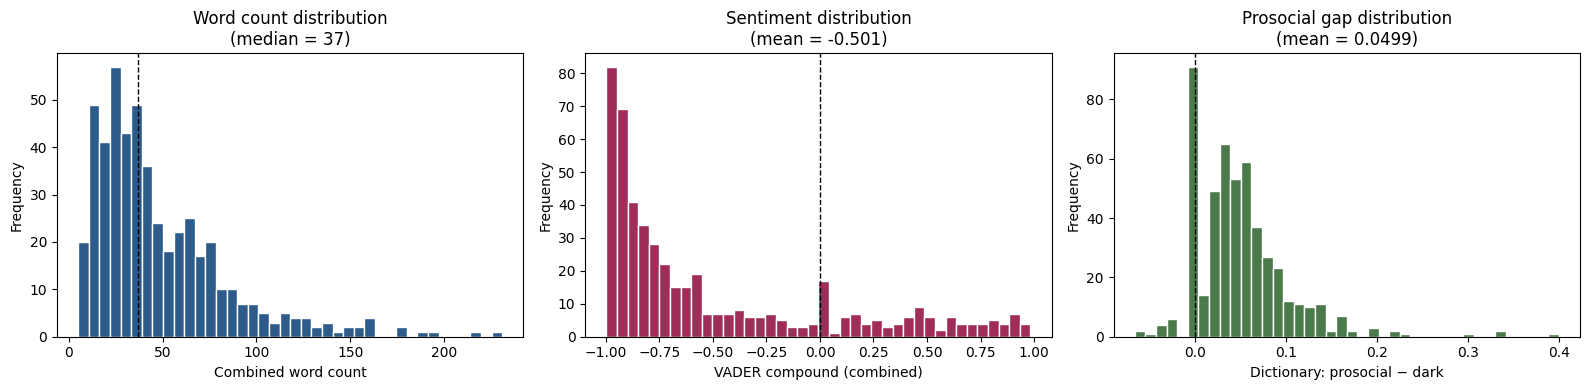

In [9]:
# === DIAGNOSTIC PLOTS ===
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Word count
axes[0].hist(df_valid['text_combined_wordcount'], bins=40, color='#2E5C8A', edgecolor='white')
axes[0].set_xlabel('Combined word count')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Word count distribution\n(median = {df_valid["text_combined_wordcount"].median():.0f})')
axes[0].axvline(df_valid['text_combined_wordcount'].median(), color='black', linestyle='--', linewidth=1)

# VADER compound
axes[1].hist(df_valid['vader_compound'], bins=40, color='#A02C5A', edgecolor='white')
axes[1].set_xlabel('VADER compound (combined)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Sentiment distribution\n(mean = {df_valid["vader_compound"].mean():.3f})')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)

# Prosocial − Dark gap
axes[2].hist(df_valid['just_prosocial_minus_dark'], bins=40, color='#4A7A4A', edgecolor='white')
axes[2].set_xlabel('Dictionary: prosocial − dark')
axes[2].set_ylabel('Frequency')
axes[2].set_title(f'Prosocial gap distribution\n(mean = {df_valid["just_prosocial_minus_dark"].mean():.4f})')
axes[2].axvline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()


In [10]:
# === SAMPLE EXTREMES ===
# Top 3 most prosocial-leaning (by dictionary)
print('=== TOP 3 MOST PROSOCIAL (dictionary) ===\n')
top_prosoc = df_valid.nlargest(3, 'just_prosocial_minus_dark')
for i, (_, row) in enumerate(top_prosoc.iterrows(), 1):
    print(f'--- #{i} (gap = {row["just_prosocial_minus_dark"]:.3f}) ---')
    print(f'  {row["text_combined"][:300]}\n')

print('\n=== TOP 3 MOST DARK (dictionary) ===\n')
top_dark = df_valid.nsmallest(3, 'just_prosocial_minus_dark')
for i, (_, row) in enumerate(top_dark.iterrows(), 1):
    print(f'--- #{i} (gap = {row["just_prosocial_minus_dark"]:.3f}) ---')
    print(f'  {row["text_combined"][:300]}\n')


=== TOP 3 MOST PROSOCIAL (dictionary) ===

--- #1 (gap = 0.400) ---
  it seemed appropriate rehabilitate darryl

--- #2 (gap = 0.333) ---
  he deserves jailtime rehabilitate and remind

--- #3 (gap = 0.333) ---
  just feel it's appropriate don't know


=== TOP 3 MOST DARK (dictionary) ===

--- #1 (gap = -0.067) ---
  it weas his choice to attack. his actions warrant this. nobody else will get hurt.

--- #2 (gap = -0.062) ---
  did that without his intention, but since one got hurt, it is an offense being careful

--- #3 (gap = -0.050) ---
  because it was a straight-up premeditated revenge killing. to keep a murdererdangerous person like daryl off of the streets indefinitely.



---

## Section 7: Export `01_basic_features.csv`

Save the full DataFrame (original columns + new text features) for use as input to Notebook 2 (classification).

**Columns added in this notebook (40 new):**
- 3 text columns: `text1_clean`, `text2_clean`, `text_combined`
- 3 word counts: `text1_wordcount`, `text2_wordcount`, `text_combined_wordcount`
- 12 VADER columns (4 × 3 texts)
- 26 Empath columns
- 10 dictionary categories + 3 aggregates


In [11]:
# === EXPORT ===
out_path = '01_basic_features.csv'
df_valid.to_csv(out_path, index=False)

n_orig_cols = len(df.columns)
n_total_cols = len(df_valid.columns)
n_new_cols = n_total_cols - n_orig_cols

print(f'✓ Exported: {out_path}')
print(f'  Rows:           {len(df_valid)}')
print(f'  Total columns:  {n_total_cols}')
print(f'  Original:       {n_orig_cols}')
print(f'  Newly added:    {n_new_cols}')
print()
print('New text-feature columns:')
new_cols = [c for c in df_valid.columns if c not in df.columns]
for c in new_cols:
    print(f'  {c}')


✓ Exported: 01_basic_features.csv
  Rows:           496
  Total columns:  202
  Original:       151
  Newly added:    51

New text-feature columns:
  vader1_neg
  vader1_neu
  vader1_pos
  vader1_compound
  vader2_neg
  vader2_neu
  vader2_pos
  vader2_compound
  vader_neg
  vader_neu
  vader_pos
  vader_compound
  empath_violence
  empath_crime
  empath_death
  empath_pain
  empath_suffering
  empath_negative_emotion
  empath_positive_emotion
  empath_anger
  empath_fear
  empath_hate
  empath_disgust
  empath_sympathy
  empath_help
  empath_government
  empath_law
  empath_order
  empath_power
  empath_family
  empath_children
  empath_healing
  empath_prison
  empath_weapon
  empath_fight
  empath_kill
  empath_trust
  empath_achievement
  just_deterrence
  just_incapacitation
  just_rehabilitation
  just_retribution
  just_norm_expression
  just_revenge
  just_suffering
  just_degradation
  just_exclusion
  just_victim_focus
  just_prosocial
  just_dark
  just_prosocial_minus_dark


In [12]:
# === DOWNLOAD ===
files.download('01_basic_features.csv')
print('\n✓ Download triggered. Save this file — it is the input to Notebook 2.')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Download triggered. Save this file — it is the input to Notebook 2.


---

## Next step: Notebook 2

Move to **`02_classification.ipynb`** which will:
1. Load `01_basic_features.csv`
2. Run zero-shot classification with **DeBERTa-v3-large-zeroshot-v2.0** (replaces BART)
3. Run zero-shot classification with **Claude Haiku 4.5** via the Anthropic API
4. Re-run the 40-sentence A1 synthetic benchmark on both classifiers (the headline "DeBERTa beats BART" comparison)
5. Export `02_classification_features.csv`

**Notebook 2 requires GPU** (T4 free tier is sufficient).
